# Set up directories 

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# This prints the current working directory
import os
print('Current working directory: ', os.getcwd())

Current working directory:  /content


In [ ]:
# You can use Linux commands like `pwd`, `cd` and `ls` to
# Also, make sure that the dataset cifar-10-batches-py is already downloaded!
!ls /content/drive/MyDrive/labs/

arrays	cifar-10-batches-py  lab_1_2024_2025  lab_2_2024_2025


In [ ]:
# After confirming the location of  path, assign it to
# `FOLDERPATH` variable
FOLDERPATH = '/content/drive/MyDrive/labs/lab_2_2024_2025/'
assert FOLDERPATH is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.insert(1, FOLDERPATH)

In [ ]:
# Having the dataset, let's change directory to
# Lab1 folder again to continue with the exercise
%cd {FOLDERPATH}

/content/drive/MyDrive/labs/lab_2_2024_2025


Note that when you see symbols like ``%`` or ``!`` before a command in Google Colab, these are not Python, but bash (Linux) commands.

# Fully-Connected Neural Nets
  

## Intro

In this exercise we will implement fully-connected networks using a modular approach.

For each layer we will implement a `forward` and a `backward` function.

The `forward` function will receive inputs, weights, and other parameters and will return both an output and a `cache` object storing data needed for the backward pass, like this:

```python
def layer_forward(x, w):
  """ Receive inputs x and weights w """
  # Do some computations ...
  z = np.dot(x, w)# ... some intermediate value
  # Do some more computations ...
  out = z# the output
   
  cache = (x, w, z, out) # Values we need to compute gradients
   
  return out, cache
```

The backward pass will receive upstream derivatives and the `cache` object, and will return gradients with respect to the inputs and weights, like this:

```python
def layer_backward(dout, cache):
  """
  Receive dout (derivative of loss with respect to outputs) and cache,
  and compute derivative with respect to inputs.
  """
  # Unpack cache values
  x, w, z, out = cache
  
  # Use values in cache to compute derivatives
  dx = np.dot(dout, w.T) # Derivative of loss with respect to x
  dw = np.dot(x.T, dout) # Derivative of loss with respect to w
  
  return dx, dw
```

After implementing a bunch of layers this way, we will be able to easily combine them to build classifiers with different architectures.

## Set up code

In [ ]:
# As usual, a bit of setup
from __future__ import print_function
import time
import numpy as np
import matplotlib.pyplot as plt
from engine.classifiers.two_layer_net import *
from engine.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from engine.solver import Solver

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

def rel_error(x, y):
  """ returns relative error """
  return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

## CIFAR-10 Data Loading and Pre-processing

Let's load the CIFAR-10 dataset

In [ ]:
from engine.data_utils import load_CIFAR10

# Load the raw CIFAR-10 data.
cifar10_dir = '/content/drive/MyDrive/labs/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


## Load .npy files

Load dataset from ``.npy`` files! This way is really faster!

In [ ]:
# Specify adrs dir, so that arrays dir is
# automatically retrieved and arrays can be loaded from it
labs_dir = '/content/drive/MyDrive/labs'
arrays_dir = os.path.join(labs_dir, 'arrays')

# Load arrays if needed. Uncomment to use!
X_train = np.load(os.path.join(arrays_dir, 'full_X_train.npy'))
y_train = np.load(os.path.join(arrays_dir, 'full_y_train.npy'))
X_test = np.load(os.path.join(arrays_dir, 'full_X_test.npy'))
y_test = np.load(os.path.join(arrays_dir, 'full_y_test.npy'))

# Num of samples for training and test
num_training = X_train.shape[0]
num_test = X_test.shape[0]

## Split data

In [ ]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data.
# We can use this for development so our code runs faster.
num_training = 45000
num_validation = 5000
num_test = 10000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (45000, 32, 32, 3)
Train labels shape:  (45000,)
Validation data shape:  (5000, 32, 32, 3)
Validation labels shape:  (5000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


## Fully Connected / Linear layer / Affine layer: forward



In the file  `engine/layers.py` we implement the `affine_forward()` function.

We test our implementation by running the following:

In [ ]:
from engine.layers import *
# Test the affine_forward function

num_inputs = 2
input_shape = (4, 5, 6)
output_dim = 3

input_size = num_inputs * np.prod(input_shape)
weight_size = output_dim * np.prod(input_shape)

x = np.linspace(-0.1, 0.5, num=input_size).reshape(num_inputs, *input_shape)
w = np.linspace(-0.2, 0.3, num=weight_size).reshape(np.prod(input_shape), output_dim)
b = np.linspace(-0.3, 0.1, num=output_dim)

out, _ = affine_forward(x, w, b)
correct_out = np.array([[ 1.49834967,  1.70660132,  1.91485297],
                        [ 3.25553199,  3.5141327,   3.77273342]])

# Compare your output with ours. The error should be around e-9 or less.
print('Testing affine_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing affine_forward function:
difference:  9.769849468192957e-10


## Fully Connected / Linear layer / Affine layer: backward



In the same folder, we also implement the  `affine_backward()` function in `engine/layers.py` and test our implementation using numeric gradient checking.

**Hint:** For the **weight** and **input** gradient, have a look at [this](http://cs231n.stanford.edu/handouts/linear-backprop.pdf) and [this](https://web.eecs.umich.edu/~justincj/teaching/eecs442/notes/linear-backprop.html).

For the **bias** gradient, have a look at [this](https://datascience.stackexchange.com/questions/20139/gradients-for-bias-terms-in-backpropagation) and [this](https://eli.thegreenplace.net/2018/backpropagation-through-a-fully-connected-layer/).

In [ ]:
# Test the affine_backward function
np.random.seed(231)
x = np.random.randn(10, 2, 3)
w = np.random.randn(6, 5)
b = np.random.randn(5)
dout = np.random.randn(10, 5)

dx_num = eval_numerical_gradient_array(lambda x: affine_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_forward(x, w, b)[0], b, dout)

_, cache = affine_forward(x, w, b)
dx, dw, db = affine_backward(dout, cache)

# The error should be around e-10 or less
print('Testing affine_backward function:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_backward function:
dx error:  5.399100368651805e-11
dw error:  9.904211865398145e-11
db error:  2.4122867568119087e-11


## ReLU activation: forward



Now, let's implement the forward pass for the ReLU activation function in the `relu_forward()` function in `engine/layers.py` and test our implementation using the following:

In [ ]:
# Test the relu_forward function

x = np.linspace(-0.5, 0.5, num=12).reshape(3, 4)

out, _ = relu_forward(x)
correct_out = np.array([[ 0.,          0.,          0.,          0.,        ],
                        [ 0.,          0.,          0.04545455,  0.13636364,],
                        [ 0.22727273,  0.31818182,  0.40909091,  0.5,       ]])

# Compare your output with ours. The error should be on the order of e-8
print('Testing relu_forward function:')
print('difference: ', rel_error(out, correct_out))

Testing relu_forward function:
difference:  4.999999798022158e-08


## ReLU activation: backward



We also implement the backward pass for the ReLU activation function in the `relu_backward()` function in `engine/layers.py` and test our implementation using numeric gradient checking.

**Hint:** For the **ReLU** gradient, have a look at [this](https://datascience.stackexchange.com/questions/19272/deep-neural-network-backpropogation-with-relu).

In [ ]:
np.random.seed(231)
x = np.random.randn(10, 10)
dout = np.random.randn(*x.shape)

dx_num = eval_numerical_gradient_array(lambda x: relu_forward(x)[0], x, dout)

_, cache = relu_forward(x)
dx = relu_backward(dout, cache)

# The error should be on the order of e-12
print('Testing relu_backward function:')
print('dx error: ', rel_error(dx_num, dx))

Testing relu_backward function:
dx error:  3.2756349136310288e-12


Sigmoid suffers from vanishing gradients problem, while ReLU produces zero gradients for negative inputs of $x$.

**Sigmoid:**

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

For large positive inputs of $x$, sigmoid goes close to 1 and, respectively, for large negative inputs of $x$, sigmoid goes very close to 0. In these two points, the gradient(slope of function) approaches 0. So, the vanishing gradient problem happens, and, this is one reason why we don't use sigmoid as an activation function in hidden layers(it is only used in the final output layer of NNs as an activation in binary tasks).

**ReLU:**

$$
\mathrm{ReLU}(x) = \max(0, x)
$$

Here, negative inputs of $x$ produce zero gradients. So, during training, if any activation produces a negative output, then, this neuron will produce zero gradients and there will be no contribution to updates from this neuron(also known as "dying ReLU" problem).

**Leaky ReLU:**

$$
\mathrm{Leaky\ ReLU}(x) =
\begin{cases}
x & \text{if } x > 0 \\
\alpha x & \text{if } x \leq 0
\end{cases}
$$

The "dying ReLU" problem drove scientists to design LeakyReLU, which ensures that for even negative inputs of $x$, gradients can take very small, non-zero, values.

## "Sandwich" layers / Stacking layers

There are some common patterns of layers that are frequently used in neural nets. For example, affine layers are frequently followed by a ReLU nonlinearity. To make these common patterns easy, we define convenience layers in the file `engine/layer_utils.py`.

Take a look at the `affine_relu_forward()` and `affine_relu_backward()` functions, and run the following to numerically gradient check the backward pass:

In [ ]:
from engine.layer_utils import affine_relu_forward, affine_relu_backward
np.random.seed(231)
x = np.random.randn(2, 3, 4)
w = np.random.randn(12, 10)
b = np.random.randn(10)
dout = np.random.randn(2, 10)

out, cache = affine_relu_forward(x, w, b)
dx, dw, db = affine_relu_backward(dout, cache)

dx_num = eval_numerical_gradient_array(lambda x: affine_relu_forward(x, w, b)[0], x, dout)
dw_num = eval_numerical_gradient_array(lambda w: affine_relu_forward(x, w, b)[0], w, dout)
db_num = eval_numerical_gradient_array(lambda b: affine_relu_forward(x, w, b)[0], b, dout)

# Relative error should be around e-10 or less
print('Testing affine_relu_forward and affine_relu_backward:')
print('dx error: ', rel_error(dx_num, dx))
print('dw error: ', rel_error(dw_num, dw))
print('db error: ', rel_error(db_num, db))

Testing affine_relu_forward and affine_relu_backward:
dx error:  2.299579177309368e-11
dw error:  8.162011105764925e-11
db error:  7.826724021458994e-12


## Loss: Softmax and SVM



Now, we implement the loss and gradient for softmax and SVM in the `softmax_loss()` and `svm_loss()` function in `engine/layers.py`.

We test if our implementations are correct by running the following:

In [ ]:
np.random.seed(231)
num_classes, num_inputs = 10, 50
x = 0.001 * np.random.randn(num_inputs, num_classes)
y = np.random.randint(num_classes, size=num_inputs)

dx_num = eval_numerical_gradient(lambda x: svm_loss(x, y)[0], x, verbose=False)
loss, dx = svm_loss(x, y)

# Test svm_loss function. Loss should be around 9 and dx error should be around the order of e-9
print('Testing svm_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))

dx_num = eval_numerical_gradient(lambda x: softmax_loss(x, y)[0], x, verbose=False)
loss, dx = softmax_loss(x, y)

# Test softmax_loss function. Loss should be close to 2.3 and dx error should be around e-8
print('\nTesting softmax_loss:')
print('loss: ', loss)
print('dx error: ', rel_error(dx_num, dx))

Testing svm_loss:
loss:  8.999602749096233
dx error:  1.4021566006651672e-09

Testing softmax_loss:
loss:  2.3025458445007376
dx error:  8.234144091578429e-09


## Two-layer network

 Next, we implement the `TwoLayerNet` class of the file `engine/classifiers/two_layer_net.py` and test our implementation with the below cell.

In [ ]:
np.random.seed(231)
N, D, H, C = 3, 5, 50, 7
X = np.random.randn(N, D)
y = np.random.randint(C, size=N)

std = 1e-3
model = TwoLayerNet(input_dim=D, hidden_dim=H, num_classes=C, weight_scale=std)

print('Testing initialization ... ')
W1_std = abs(model.params['W1'].std() - std)
b1 = model.params['b1']
W2_std = abs(model.params['W2'].std() - std)
b2 = model.params['b2']
assert W1_std < std / 10, 'First layer weights do not seem right'
assert np.all(b1 == 0), 'First layer biases do not seem right'
assert W2_std < std / 10, 'Second layer weights do not seem right'
assert np.all(b2 == 0), 'Second layer biases do not seem right'

print('Testing test-time forward pass ... ')
model.params['W1'] = np.linspace(-0.7, 0.3, num=D*H).reshape(D, H)
model.params['b1'] = np.linspace(-0.1, 0.9, num=H)
model.params['W2'] = np.linspace(-0.3, 0.4, num=H*C).reshape(H, C)
model.params['b2'] = np.linspace(-0.9, 0.1, num=C)
X = np.linspace(-5.5, 4.5, num=N*D).reshape(D, N).T
scores = model.loss(X)
correct_scores = np.asarray(
  [[11.53165108,  12.2917344,   13.05181771,  13.81190102,  14.57198434, 15.33206765,  16.09215096],
   [12.05769098,  12.74614105,  13.43459113,  14.1230412,   14.81149128, 15.49994135,  16.18839143],
   [12.58373087,  13.20054771,  13.81736455,  14.43418138,  15.05099822, 15.66781506,  16.2846319 ]])
scores_diff = np.abs(scores - correct_scores).sum()
assert scores_diff < 1e-6, 'Problem with test-time forward pass'

print('Testing training loss (no regularization)')
y = np.asarray([0, 5, 1])
loss, grads = model.loss(X, y)
correct_loss = 3.4702243556
assert abs(loss - correct_loss) < 1e-10, 'Problem with training-time loss'

model.reg = 1.0
loss, grads = model.loss(X, y)
correct_loss = 26.5948426952
assert abs(loss - correct_loss) < 1e-10, 'Problem with regularization loss'

# Errors should be around e-7 or less
for reg in [0.0, 0.7]:
  print('Running numeric gradient check with reg = ', reg)
  model.reg = reg
  loss, grads = model.loss(X, y)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))

Testing initialization ... 
Testing test-time forward pass ... 
Testing training loss (no regularization)
Running numeric gradient check with reg =  0.0
W1 relative error: 1.83e-08
W2 relative error: 3.20e-10
b1 relative error: 9.83e-09
b2 relative error: 4.33e-10
Running numeric gradient check with reg =  0.7
W1 relative error: 2.53e-07
W2 relative error: 2.85e-08
b1 relative error: 1.56e-08
b2 relative error: 9.09e-10


## Solver

Almost all the job is done in the file `engine/solver.py`  Navigate through it!

Next, we have to implement the `sgd()` function in `engine/optim.py` and then we use a `Solver` instance to train a `TwoLayerNet` 

In [ ]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
model = TwoLayerNet(input_size, hidden_size, num_classes)
solver = None
data = {"X_train":X_train, "y_train":y_train, "X_val":X_val, \
        "y_val":y_val, "X_test":X_test, "y_test":y_test}


# We use a Solver instance to train a TwoLayerNet                                    
data["X_train"] = data["X_train"].reshape(data["X_train"].shape[0], -1)
data["X_val"] = data["X_val"].reshape(data["X_val"].shape[0], -1)
data["X_test"] = data["X_test"].reshape(data["X_test"].shape[0], -1)

solver = Solver(
    model=model,
    data=data,
    update_rule="sgd",
    optim_config={"learning_rate": 1e-3},
    lr_decay=0.95,
    num_epochs=15,
    batch_size=100,
    print_every=100,
)


solver.train()


(Iteration 1 / 6750) loss: 2.302792
(Epoch 0 / 15) train acc: 0.089000; val_acc: 0.104000
(Iteration 101 / 6750) loss: 2.342959
(Iteration 201 / 6750) loss: 2.242185
(Iteration 301 / 6750) loss: 2.289693
(Iteration 401 / 6750) loss: 2.184937
(Epoch 1 / 15) train acc: 0.158000; val_acc: 0.146000
(Iteration 501 / 6750) loss: 2.266333
(Iteration 601 / 6750) loss: 2.254416
(Iteration 701 / 6750) loss: 2.304168
(Iteration 801 / 6750) loss: 2.045170
(Epoch 2 / 15) train acc: 0.168000; val_acc: 0.184400
(Iteration 901 / 6750) loss: 2.135127
(Iteration 1001 / 6750) loss: 2.288712
(Iteration 1101 / 6750) loss: 2.163784
(Iteration 1201 / 6750) loss: 2.256188
(Iteration 1301 / 6750) loss: 2.005108
(Epoch 3 / 15) train acc: 0.140000; val_acc: 0.136400
(Iteration 1401 / 6750) loss: 2.159594
(Iteration 1501 / 6750) loss: 2.143956
(Iteration 1601 / 6750) loss: 2.181159
(Iteration 1701 / 6750) loss: 1.962880
(Epoch 4 / 15) train acc: 0.192000; val_acc: 0.178800
(Iteration 1801 / 6750) loss: 2.012108
(

## Debug the training

With the default parameters we provided above, we get a validation accuracy of about `32%` on the validation set. This isn't so good.

One strategy for getting insight into what's wrong is to plot the loss function and the accuracies on the training and validation sets during optimization.

Another strategy is to visualize the weights that were learned in the first layer of the network. In most neural networks trained on visual data, the first layer weights typically show some visible structure when visualized.

### Visualize loss and accuracy

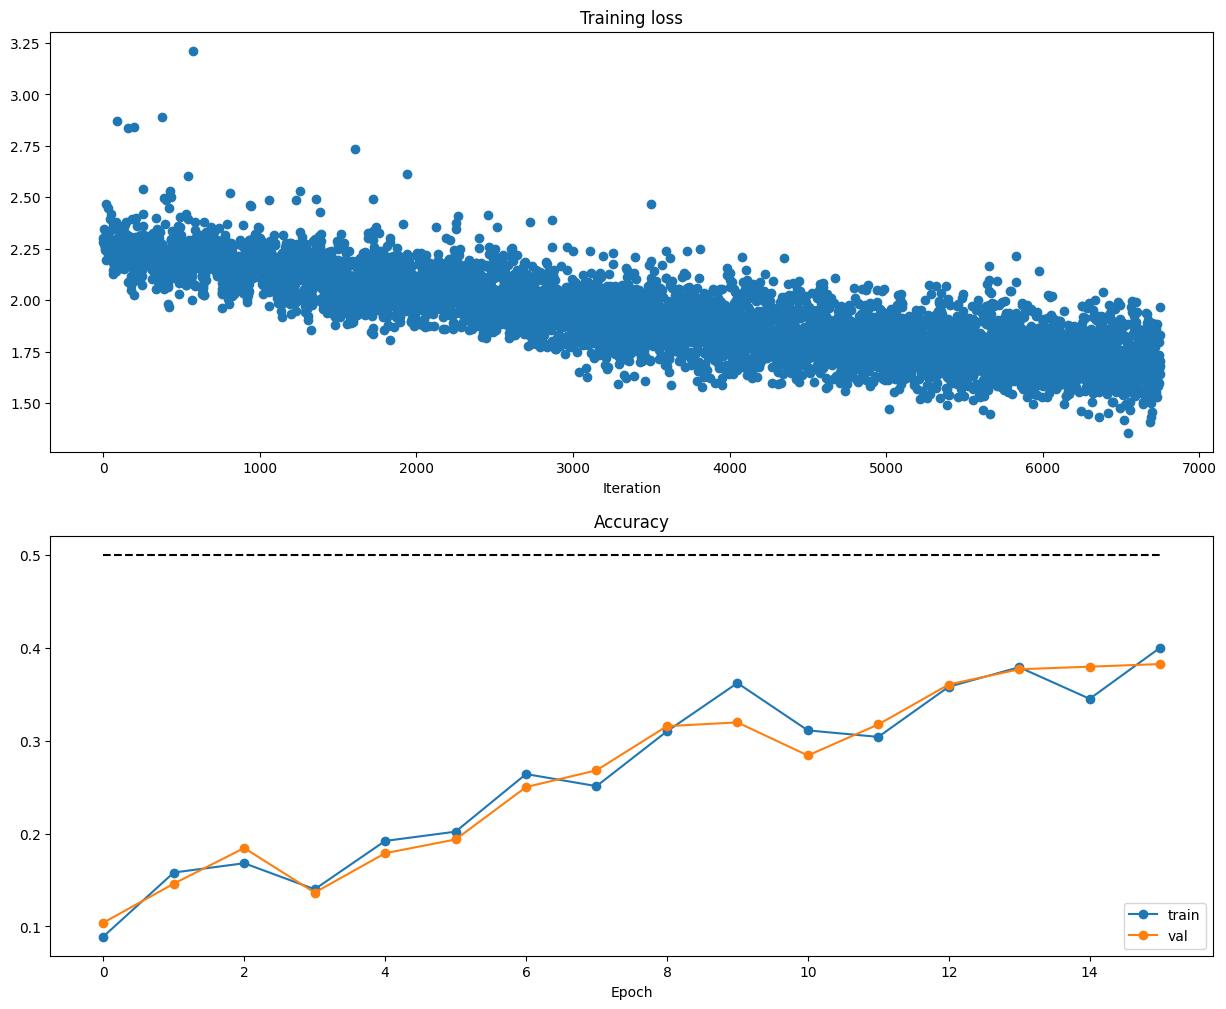

In [ ]:
# We run this cell to visualize training loss and train / val accuracy

plt.subplot(2, 1, 1)
plt.title('Training loss')
plt.plot(solver.loss_history, 'o')
plt.xlabel('Iteration')

plt.subplot(2, 1, 2)
plt.title('Accuracy')
plt.plot(solver.train_acc_history, '-o', label='train')
plt.plot(solver.val_acc_history, '-o', label='val')
plt.plot([0.5] * len(solver.val_acc_history), 'k--')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.gcf().set_size_inches(15, 12)
plt.show()

### Visualize weights

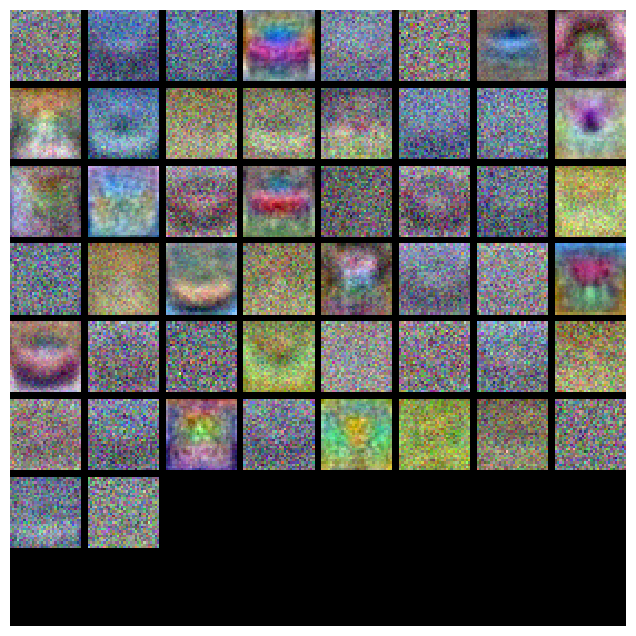

In [ ]:
from engine.vis_utils import visualize_grid

# Visualize the weights of the network

def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(model)

## Hyperparameter Tuning

From the visualizations above, we can observe that the loss decreases almost linearly. This suggests that the learning rate may be too small, since the model is improving slowly and may not be taking large enough optimization steps.

Also, the training and validation accuracies are very close to each other. This indicates that the model may have low capacity and is likely underfitting the data. In this case, increasing the size of the network, for example by using a larger hidden layer, could improve performance. On the other hand, if the model becomes too large, we may start to observe overfitting, which would appear as a large gap between training and validation accuracy.

Hyperparameter tuning is an important part of training neural networks. It helps us understand how different choices affect the final performance. In the experiments below, we test different values for several hyperparameters, including the hidden layer size, learning rate, number of training epochs, and regularization strength. We can also experiment with learning rate decay, although good performance may still be achieved using the default value.

The goal of this experiment is to obtain the highest possible validation accuracy on CIFAR-10 using a fully connected neural network. A validation accuracy of around 46% or higher can be used as a strong reference target.

To achieve this, we perform a hyperparameter search by trying different combinations of learning rates, hidden layer sizes, regularization strengths, and other strategies that may improve the model.

Some useful directions to explore are:

- **Hyperparameter tuning:** Try different learning rates, hidden layer sizes, batch sizes, numbers of epochs, and regularization strengths to find a stronger configuration.

- **Dimensionality reduction:** Consider using PCA to reduce the dimensionality of the input features. This may simplify the feature space and help the model train more effectively.

- **Regularization techniques:** Use methods such as L2 regularization or dropout to reduce overfitting and improve generalization.

In [ ]:
best_model = None

# We tune hyperparameters using the validation set. Store our best trained  
# model in best_model.                                                                                                                                       #

learning_rates = [0.0004, 0.0005, 0.0006]
hidden_sizes = [300, 350]
batch_sizes = [96, 128]
num_epochs = 20

best_val_acc = 0

reg = 0.03


for lr in learning_rates:
    for hidden_size in hidden_sizes:
        for batch_size in batch_sizes:
            print(f"Training with learning rate = {lr}, hidden size = {hidden_size}, batch size = {batch_size}")

            model = TwoLayerNet(input_dim=32 * 32 * 3, hidden_dim=hidden_size, num_classes=10, reg=reg)


            solver = Solver(
                model=model,
                data=data,
                update_rule="sgd",
                optim_config={"learning_rate": lr},
                lr_decay=0.9,
                num_epochs=num_epochs,
                batch_size=batch_size,
                print_every=None,
                verbose=False,
            )

            solver.train()

            print(f"Validation accuracy: {solver.best_val_acc:.3f}")

            if solver.best_val_acc > best_val_acc:
                best_val_acc = solver.best_val_acc
                best_model = model

print(f"Best validation accuracy: {best_val_acc}")

Training with learning rate = 0.0004, hidden size = 300, batch size = 96
Validation accuracy: 0.513
Training with learning rate = 0.0004, hidden size = 300, batch size = 128
Validation accuracy: 0.516
Training with learning rate = 0.0004, hidden size = 350, batch size = 96
Validation accuracy: 0.529
Training with learning rate = 0.0004, hidden size = 350, batch size = 128
Validation accuracy: 0.520
Training with learning rate = 0.0005, hidden size = 300, batch size = 96
Validation accuracy: 0.523
Training with learning rate = 0.0005, hidden size = 300, batch size = 128
Validation accuracy: 0.519
Training with learning rate = 0.0005, hidden size = 350, batch size = 96
Validation accuracy: 0.524
Training with learning rate = 0.0005, hidden size = 350, batch size = 128
Validation accuracy: 0.518
Training with learning rate = 0.0006, hidden size = 300, batch size = 96
Validation accuracy: 0.523
Training with learning rate = 0.0006, hidden size = 300, batch size = 128
Validation accuracy: 0

## Test your model!

We run our best model on the validation and test sets (expected accuracy above 45% in both validation and test sets).

In [ ]:
print(best_model)
y_val_pred = np.argmax(best_model.loss(data['X_val']), axis=1)
print('Validation set accuracy: ', (y_val_pred == data['y_val']).mean())

Validation set accuracy:  0.5286


In [ ]:
y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())

Test set accuracy:  0.5154


## Try alternative Optimizers

After optimizing the model with vanilla SGD, we now examine how different optimization methods affect training.

In this final experiment, we implement `sgd_momentum()`, `rmsprop()`, and `adam()` in `engine/optim.py`. These functions allow the model to be trained using SGD with Momentum, RMSProp, and Adam.

Once the optimizers are implemented, we train a `TwoLayerNet` using a `Solver` instance for each optimization method. We then compare the optimizers based on validation accuracy and training speed.

In [ ]:
import time

best_model = None
best_val_acc_per_optimizer = {}
training_time_per_optimizer = {}
overall_best_val_acc = 0
optimizers = ["sgd_momentum", "rmsprop", "adam"]
learning_rates = [0.0001] # I also tried learning_rate = 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.00008
hidden_sizes = 300 # I also tried  hidden_size = 250, 350
batch_sizes = [256] # I also tried  batch_size = 96, 128, 512
reg_values = [0.01] # I also tried reg_values = 0.02, 0.05
num_epochs = 20 # and i also tried 50 epochs because i hade small learning rate = 0.00008 as i said before which have 0.02 better resulsts but i was afraid for over fitting
# i conclude with this parameters and didnt show you the others that i said in the comments because it took me 9 hours to run for 3 values to each hyper parameter. :)
for opt in optimizers:
    start_time = time.time()
    best_val_acc = 0

    for lr in learning_rates:
        for batch_size in batch_sizes:
            for reg in reg_values:
                print(f"Training with optimizer: {opt}, lr: {lr}, hidden_size: {hidden_sizes}, batch_size: {batch_size}, reg: {reg}")


                model = TwoLayerNet(input_dim=input_size, hidden_dim=hidden_sizes, num_classes=num_classes, reg=reg)
                solver = Solver(
                    model=model,
                    data=data,
                    update_rule=opt,
                    optim_config={"learning_rate": lr},
                    lr_decay=0.95,
                    num_epochs=num_epochs,
                    batch_size=batch_size,
                    print_every=None,
                    verbose=False,
                )
                solver.train()

                val_acc = solver.best_val_acc
                print(f"Validation accuracy: {val_acc:.4f}")


                if val_acc > best_val_acc:
                    best_val_acc = val_acc

    end_time = time.time()
    training_time = end_time - start_time
    training_time_per_optimizer[opt] = training_time
    best_val_acc_per_optimizer[opt] = best_val_acc


    if best_val_acc > overall_best_val_acc:
        overall_best_val_acc = best_val_acc
        best_model = model

print("\nBest validation accuracies and training times per optimizer:")
for opt in optimizers:
    print(f"{opt}: Validation Accuracy = {best_val_acc_per_optimizer[opt]:.4f}, Training Time = {training_time_per_optimizer[opt]:.2f} seconds")


print(f"\nBest overall validation accuracy: {overall_best_val_acc:.4f}")

y_test_pred = np.argmax(best_model.loss(data['X_test']), axis=1)
print('Test set accuracy: ', (y_test_pred == data['y_test']).mean())



Training with optimizer: sgd_momentum, lr: 0.0001, hidden_size: 300, batch_size: 256, reg: 0.01
Validation accuracy: 0.5180
Training with optimizer: rmsprop, lr: 0.0001, hidden_size: 300, batch_size: 256, reg: 0.01
Validation accuracy: 0.4722
Training with optimizer: adam, lr: 0.0001, hidden_size: 300, batch_size: 256, reg: 0.01
Validation accuracy: 0.4866

Best validation accuracies and training times per optimizer:
sgd_momentum: Validation Accuracy = 0.5180, Training Time = 212.38 seconds
rmsprop: Validation Accuracy = 0.4722, Training Time = 226.47 seconds
adam: Validation Accuracy = 0.4866, Training Time = 255.30 seconds

Best overall validation accuracy: 0.5180
Test set accuracy:  0.5074


## Reducing the Gap Between Training and Test Accuracy

When a neural network achieves much higher training accuracy than test accuracy, this is usually a sign of overfitting. The model has learned patterns that are too specific to the training data and does not generalize well to unseen examples.

One way to reduce this gap is to train the model on a larger dataset. With more training examples, the model is exposed to a wider variety of patterns and is less likely to memorize individual samples. This helps the network learn more general features that can improve performance on test data.

Another effective approach is to increase the regularization strength. Regularization methods such as L2 regularization or weight decay penalize overly complex models by discouraging large weights. This encourages the network to learn simpler and more robust patterns instead of fitting noise or details that only appear in the training set.

Adding more hidden units is not usually the best solution when the model is already overfitting. Increasing the number of hidden units makes the network more powerful, but it also increases its capacity to memorize the training data. This can make the gap between training and test accuracy even larger.

Overall, the main goal is to improve generalization. Training with more data and applying stronger regularization are both effective ways to reduce overfitting and narrow the difference between training and test performance.